# 👕 FashionMNIST Image Classification using Multi-Layer Perceptron (MLP)

## 🎯 Objective

The goal of this project is to build and train a Multi-Layer Perceptron (MLP) using PyTorch to classify grayscale images from the Fashion-MNIST dataset into one of 10 clothing categories.

### Tasks

- Load the Fashion-MNIST dataset
- Preprocess the images
- Build an MLP model (784 → 256 → 128 → 10)
- Train using the Adam optimizer
- Evaluate the model on the test dataset
- Analyze the model's performance using accuracy and a confusion matrix

---

## Dataset Overview

Fashion-MNIST is a dataset of 70,000 grayscale images of clothing items.

- Training Images: 60,000
- Test Images: 10,000
- Image Size: 28 × 28 pixels
- Number of Classes: 10

### Class Labels

| Label | Category |
|------:|----------------|
| 0 | T-shirt / Top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

In [1]:
# Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# Check PyTorch version

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.13.0+cpu


In [3]:
# Check GPU Availability

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


## Load the Dataset

The Fashion-MNIST dataset is downloaded using `torchvision.datasets.FashionMNIST`.

Each image is converted into a PyTorch tensor using the `ToTensor()` transformation.

In [4]:
# Transform images into tensors

transform = transforms.ToTensor()

# Training Dataset

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Test Dataset

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [5]:
# Display dataset information

print("Training Samples:", len(train_dataset))
print("Testing Samples :", len(test_dataset))

Training Samples: 60000
Testing Samples : 10000


In [6]:
# Class Names

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(class_names)

['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


## Explore the Dataset

Before training a model, it is good practice to inspect the dataset.

In this section, we display a few sample images along with their corresponding class labels to understand the type of data the model will learn from.

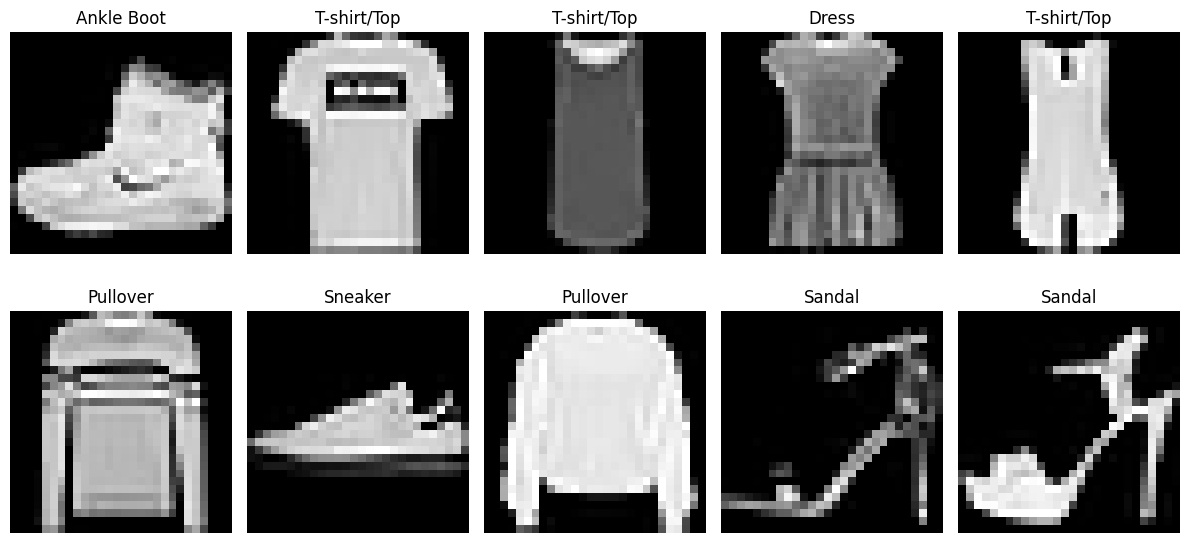

In [8]:
# Display sample images

plt.figure(figsize=(12, 6))

for i in range(10):
    image, label = train_dataset[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Create DataLoaders

Deep learning models are trained in **batches** instead of loading the entire dataset into memory at once.

PyTorch provides the `DataLoader` class to efficiently:
- Divide the dataset into batches
- Shuffle the training data
- Load data efficiently during training

In [9]:
# Create DataLoaders

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
# Check one batch

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([64, 1, 28, 28])
Label Batch Shape : torch.Size([64])


## Flatten the Images

An MLP cannot process 2D images directly.

Each 28 × 28 image must be converted into a one-dimensional vector containing:

28 × 28 = 784 features.

The flattening operation will be performed inside the model during the forward pass using `torch.flatten()`.

## Build the Multi-Layer Perceptron (MLP)

The MLP used in this project has the following architecture:

**784 → 256 → 128 → 10**

- Input Layer: 784 neurons (28 × 28 flattened image)
- Hidden Layer 1: 256 neurons + ReLU + Dropout(0.3)
- Hidden Layer 2: 128 neurons + ReLU + Dropout(0.3)
- Output Layer: 10 neurons (one for each clothing category)

In [11]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
# Create the model

model = FashionMLP().to(device)

print(model)

FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Define the Loss Function and Optimizer

For this multi-class classification problem:

- **Loss Function:** CrossEntropyLoss
- **Optimizer:** Adam
- **Learning Rate:** 0.001

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Verify the Model

Before training, it is good practice to verify that the model produces outputs with the expected shape.

For a batch of 64 images, the output should have shape:

(64, 10)

where each row contains scores for the 10 clothing classes.

In [15]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([64, 1, 28, 28])
Output Shape: torch.Size([64, 10])


## Train the Model

The training process consists of the following steps for each epoch:

1. Load a batch of images.
2. Move the data to the selected device (CPU/GPU).
3. Perform a forward pass.
4. Compute the loss.
5. Perform backpropagation.
6. Update the model parameters.
7. Calculate training accuracy.
8. Store the loss and accuracy for visualization.

In [16]:
# Lists to store training history

train_losses = []
train_accuracies = []

epochs = 20

In [17]:
# Training Loop

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward Pass
        outputs = model(images)

        # Compute Loss
        loss = criterion(outputs, labels)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/20] Loss: 0.5959 Accuracy: 78.56%
Epoch [2/20] Loss: 0.4226 Accuracy: 84.78%
Epoch [3/20] Loss: 0.3867 Accuracy: 86.02%
Epoch [4/20] Loss: 0.3649 Accuracy: 86.69%
Epoch [5/20] Loss: 0.3509 Accuracy: 87.19%
Epoch [6/20] Loss: 0.3373 Accuracy: 87.62%
Epoch [7/20] Loss: 0.3290 Accuracy: 87.94%
Epoch [8/20] Loss: 0.3176 Accuracy: 88.35%
Epoch [9/20] Loss: 0.3114 Accuracy: 88.57%
Epoch [10/20] Loss: 0.3050 Accuracy: 88.70%
Epoch [11/20] Loss: 0.2980 Accuracy: 88.96%
Epoch [12/20] Loss: 0.2933 Accuracy: 89.08%
Epoch [13/20] Loss: 0.2870 Accuracy: 89.17%
Epoch [14/20] Loss: 0.2845 Accuracy: 89.36%
Epoch [15/20] Loss: 0.2773 Accuracy: 89.69%
Epoch [16/20] Loss: 0.2721 Accuracy: 89.80%
Epoch [17/20] Loss: 0.2715 Accuracy: 89.87%
Epoch [18/20] Loss: 0.2684 Accuracy: 89.90%
Epoch [19/20] Loss: 0.2627 Accuracy: 90.05%
Epoch [20/20] Loss: 0.2608 Accuracy: 90.16%


## Plot Training Loss

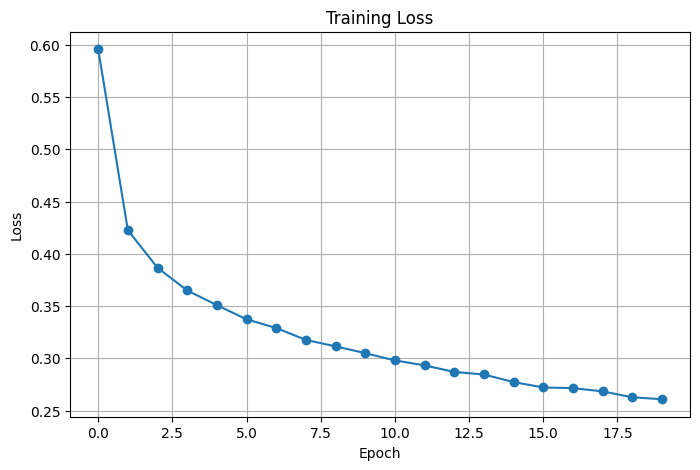

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig("images/training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot Training Accuracy

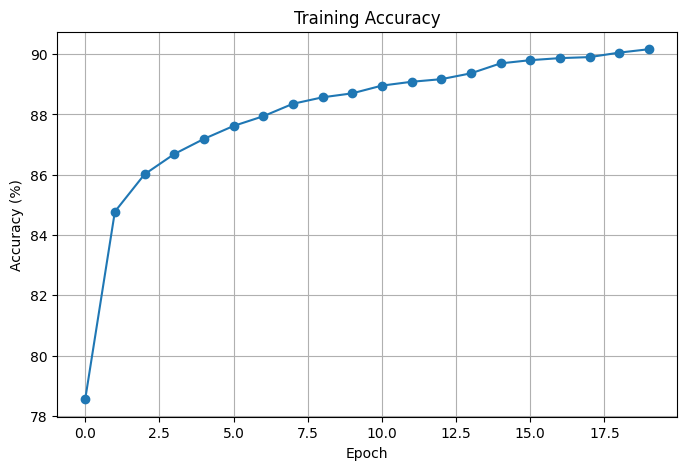

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.savefig("images/training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluate the Model

After training, we evaluate the model on the test dataset to measure its performance on unseen data.

The evaluation metric used is **classification accuracy**.

In [21]:
# Evaluation Mode
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 89.03%


## Per-Class Accuracy

Overall accuracy tells us how well the model performs on average.

Per-class accuracy shows how well the model performs on each clothing category individually.

In [22]:
# Calculate Per-Class Accuracy

class_correct = [0] * 10
class_total = [0] * 10

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        for label, prediction in zip(labels, predicted):
            class_total[label.item()] += 1
            if label == prediction:
                class_correct[label.item()] += 1

print("Per-Class Accuracy:\n")

for i in range(10):

    accuracy = 100 * class_correct[i] / class_total[i]

    print(f"{class_names[i]:15}: {accuracy:.2f}%")

Per-Class Accuracy:

T-shirt/Top    : 84.50%
Trouser        : 97.20%
Pullover       : 81.30%
Dress          : 92.40%
Coat           : 79.20%
Sandal         : 96.70%
Shirt          : 69.60%
Sneaker        : 95.70%
Bag            : 97.40%
Ankle Boot     : 96.30%


## Confusion Matrix

A confusion matrix helps us understand which classes are correctly classified and which classes are commonly confused with one another.

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

In [24]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

<Figure size 1000x800 with 0 Axes>

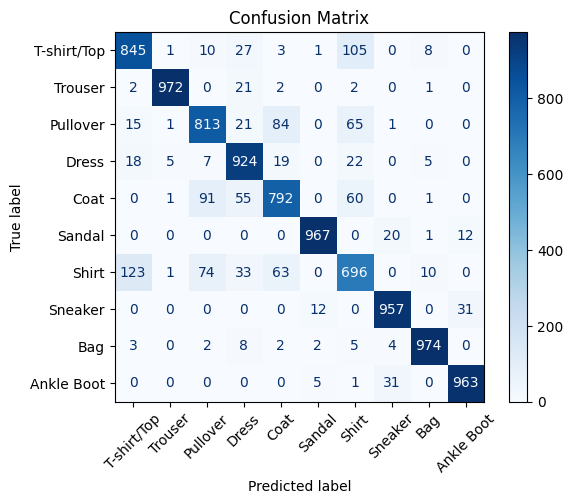

In [34]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Model Analysis

The confusion matrix helps identify which clothing categories are frequently misclassified.

Examples of commonly confused classes include:

- Shirt ↔ T-shirt/Top
- Pullover ↔ Coat
- Sneaker ↔ Ankle Boot

These categories have similar visual characteristics, making them more challenging for an MLP to distinguish.

A Convolutional Neural Network (CNN), which preserves spatial information, generally performs better on image classification tasks.

## Save the Model

Saving the trained model allows it to be reused later without retraining.

In [27]:
torch.save(
    model.state_dict(),
    "saved_model/fashion_mnist_mlp.pth"
)
print("Model saved successfully!")

Model saved successfully!


# ✅ Conclusion

In this project, we successfully built and trained a Multi-Layer Perceptron (MLP) using PyTorch to classify images from the Fashion-MNIST dataset.

### Key Learnings

- Loaded and explored the Fashion-MNIST dataset.
- Built an MLP with the architecture **784 → 256 → 128 → 10**.
- Used **ReLU** activation and **Dropout** for regularization.
- Trained the model using the **Adam** optimizer.
- Evaluated the model using overall and per-class accuracy.
- Visualized performance using a confusion matrix.
- Saved the trained model for future use.

This project demonstrates the complete deep learning workflow for an image classification task using a fully connected neural network.